# **CENG 463 – Introduction to Machine Learning HW2**

## **TASK 1: BAG OF WORDS**

Vocabulary: ['victory', 'team', 'fan', 'export', 'sector', 'product', 'committee', 'party', 'law']

Sports Document:
Frequency vector (1x9): [3, 5, 3, 0, 0, 0, 0, 0, 0]
  'victory': 3 occurrences
  'team': 5 occurrences
  'fan': 3 occurrences
  'export': 0 occurrences
  'sector': 0 occurrences
  'product': 0 occurrences
  'committee': 0 occurrences
  'party': 0 occurrences
  'law': 0 occurrences

Politics Document:
Frequency vector (1x9): [0, 0, 0, 0, 0, 0, 5, 4, 5]
  'victory': 0 occurrences
  'team': 0 occurrences
  'fan': 0 occurrences
  'export': 0 occurrences
  'sector': 0 occurrences
  'product': 0 occurrences
  'committee': 5 occurrences
  'party': 4 occurrences
  'law': 5 occurrences

Economy Document:
Frequency vector (1x9): [0, 0, 0, 5, 3, 3, 0, 0, 0]
  'victory': 0 occurrences
  'team': 0 occurrences
  'fan': 0 occurrences
  'export': 5 occurrences
  'sector': 3 occurrences
  'product': 3 occurrences
  'committee': 0 occurrences
  'party': 0 occurrences
  'law': 0 occurrence

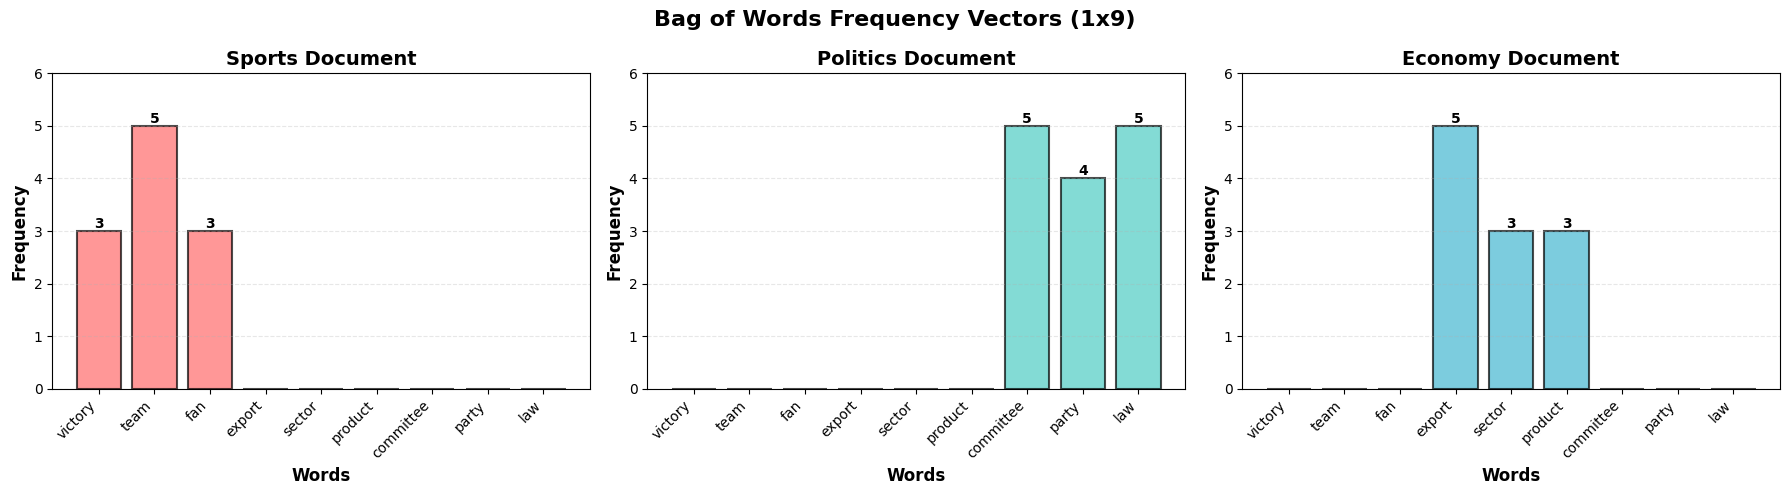

✓ Saved: task1_bow_comparison.png


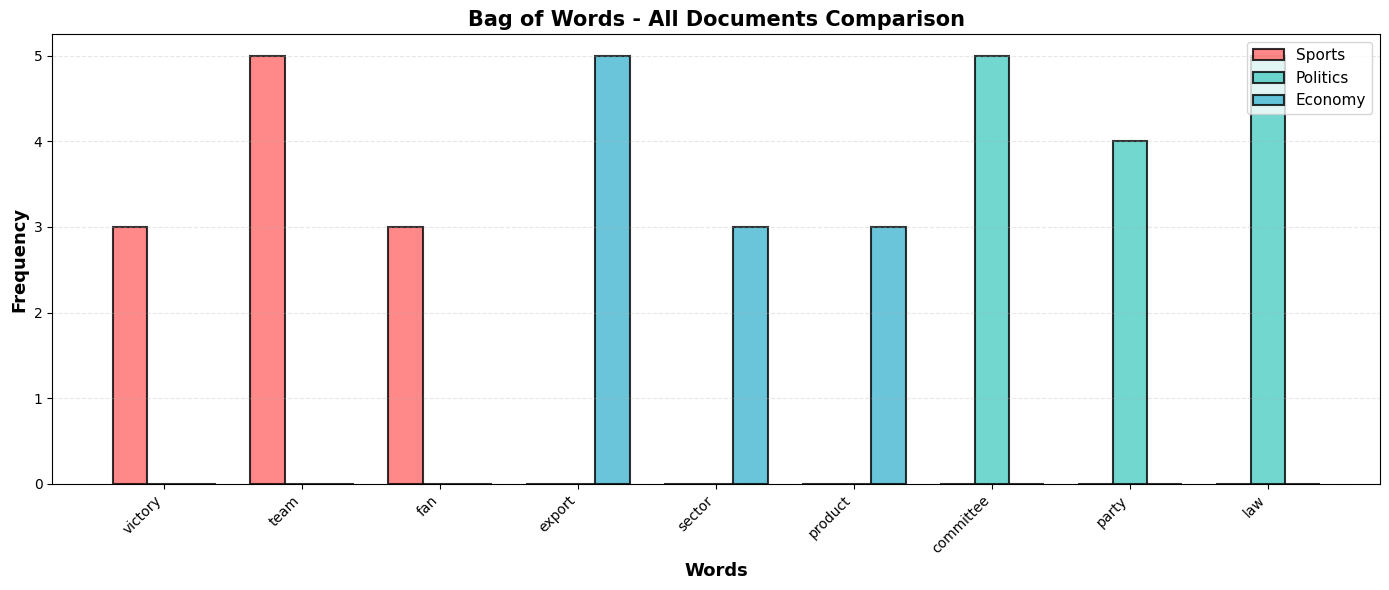


TASK 1 SUMMARY
Frequency vectors (1x9) for three documents:
  Sports    : [3, 5, 3, 0, 0, 0, 0, 0, 0]
  Politics  : [0, 0, 0, 0, 0, 0, 5, 4, 5]
  Economy   : [0, 0, 0, 5, 3, 3, 0, 0, 0]


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Read vocabulary
with open('words.txt', 'r', encoding='utf-8') as f:
    vocabulary = [word.strip().lower() for word in f.readlines()]

print("Vocabulary:", vocabulary)
print()

# Read documents
documents = {
    'Sports': open('sports.txt', 'r', encoding='utf-8').read().lower(),
    'Politics': open('politics.txt', 'r', encoding='utf-8').read().lower(),
    'Economy': open('economy.txt', 'r', encoding='utf-8').read().lower()
}

# Create Bag of Words frequency vectors
bow_vectors = {}
for doc_name, doc_text in documents.items():
    # Count occurrences of each word in vocabulary
    frequencies = []
    for word in vocabulary:
        count = doc_text.count(word)
        frequencies.append(count)
    bow_vectors[doc_name] = frequencies
    
    print(f"{doc_name} Document:")
    print(f"Frequency vector (1x9): {frequencies}")
    for i, word in enumerate(vocabulary):
        print(f"  '{word}': {frequencies[i]} occurrences")
    print()

# Visualization - Individual bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Bag of Words Frequency Vectors (1x9)', fontsize=16, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, (doc_name, color) in enumerate(zip(['Sports', 'Politics', 'Economy'], colors)):
    ax = axes[idx]
    frequencies = bow_vectors[doc_name]
    
    bars = ax.bar(vocabulary, frequencies, color=color, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_xlabel('Words', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title(f'{doc_name} Document', fontsize=14, fontweight='bold')
    ax.set_ylim(0, max(max(f) for f in bow_vectors.values()) + 1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('task1_bow_histogram.png', dpi=300, bbox_inches='tight')
print("✓ Saved: task1_bow_histogram.png")
plt.show()

# Comparison chart
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(vocabulary))
width = 0.25

bars1 = ax.bar(x - width, bow_vectors['Sports'], width, label='Sports', 
               color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x, bow_vectors['Politics'], width, label='Politics', 
               color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=1.5)
bars3 = ax.bar(x + width, bow_vectors['Economy'], width, label='Economy', 
               color='#45B7D1', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Words', fontsize=13, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=13, fontweight='bold')
ax.set_title('Bag of Words - All Documents Comparison', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(vocabulary)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('task1_bow_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: task1_bow_comparison.png")
plt.show()

print("\n" + "="*60)
print("TASK 1 SUMMARY")
print("="*60)
print("Frequency vectors (1x9) for three documents:")
for doc_name, frequencies in bow_vectors.items():
    print(f"  {doc_name:10s}: {frequencies}")

## **TASK 2: TEXT CLASSIFICATION**

In [2]:
import numpy as np
import pandas as pd
from collections import Counter
from math import log, sqrt
import matplotlib.pyplot as plt

# Sample dataset: 7 training messages + 3 test messages
training_messages = [
    ("Win free money now", "Spam"),
    ("Free prize winner announcement", "Spam"),
    ("Click here for free gift", "Spam"),
    ("Meeting scheduled for tomorrow", "Normal"),
    ("Project deadline next week", "Normal"),
    ("Lunch meeting at noon", "Normal"),
    ("Conference call tomorrow", "Normal")
]

test_messages = [
    "Free tickets available",
    "Team meeting tomorrow",
    "Winner congratulations prize"
]

print("="*60)
print("TASK 2: SPAM CLASSIFICATION")
print("="*60)
print("\nTraining Dataset:")
for i, (msg, label) in enumerate(training_messages, 1):
    print(f"  {i}. [{label:6s}] {msg}")

print(f"\nTest Messages:")
for i, msg in enumerate(test_messages, 1):
    print(f"  {i}. {msg}")

TASK 2: SPAM CLASSIFICATION

Training Dataset:
  1. [Spam  ] Win free money now
  2. [Spam  ] Free prize winner announcement
  3. [Spam  ] Click here for free gift
  4. [Normal] Meeting scheduled for tomorrow
  5. [Normal] Project deadline next week
  6. [Normal] Lunch meeting at noon
  7. [Normal] Conference call tomorrow

Test Messages:
  1. Free tickets available
  2. Team meeting tomorrow
  3. Winner congratulations prize


### **Step 1: Chi-Square Feature Selection**

In [3]:
# Extract all words from training data
all_words = set()
for msg, _ in training_messages:
    words = msg.lower().split()
    all_words.update(words)

# Calculate Chi-Square for each word
def calculate_chi_square(word, messages):
    """
    Calculate chi-square statistic for a word
    Contingency table:
                Spam    Normal   Total
    Contains     a        b      a+b
    Not Contains c        d      c+d
    Total       a+c      b+d      N
    
    χ² = N * (ad - bc)² / [(a+b)(c+d)(a+c)(b+d)]
    """
    word = word.lower()
    
    # Count occurrences
    a = sum(1 for msg, label in messages if word in msg.lower() and label == "Spam")
    b = sum(1 for msg, label in messages if word in msg.lower() and label == "Normal")
    c = sum(1 for msg, label in messages if word not in msg.lower() and label == "Spam")
    d = sum(1 for msg, label in messages if word not in msg.lower() and label == "Normal")
    
    N = len(messages)
    
    # Calculate chi-square
    numerator = N * (a * d - b * c) ** 2
    denominator = (a + b) * (c + d) * (a + c) * (b + d)
    
    if denominator == 0:
        return 0, a, b, c, d
    
    chi_square = numerator / denominator
    
    return chi_square, a, b, c, d

# Example calculation for "free"
print("Example: Chi-Square calculation for word 'free'")
print("="*60)
chi2, a, b, c, d = calculate_chi_square("free", training_messages)
N = len(training_messages)

print(f"\nContingency Table for 'free':")
print("                Spam    Normal   Total")
print(f"Contains         {a}        {b}       {a+b}")
print(f"Not Contains     {c}        {d}       {c+d}")
print(f"Total            {a+c}        {b+d}       {N}")

print(f"\nFormula: χ² = N × (ad - bc)² / [(a+b)(c+d)(a+c)(b+d)]")
print(f"         χ² = {N} × ({a}×{d} - {b}×{c})² / [({a+b})×({c+d})×({a+c})×({b+d})]")
print(f"         χ² = {N} × ({a*d} - {b*c})² / [{(a+b) * (c+d) * (a+c) * (b+d)}]")
print(f"         χ² = {N} × {(a*d - b*c)**2} / [{(a+b) * (c+d) * (a+c) * (b+d)}]")
print(f"         χ² = {chi2:.4f}")

# Calculate chi-square for all words
chi_square_scores = {}
for word in all_words:
    chi2, _, _, _, _ = calculate_chi_square(word, training_messages)
    chi_square_scores[word] = chi2

# Sort and get top features
sorted_features = sorted(chi_square_scores.items(), key=lambda x: x[1], reverse=True)

print("\n\nChi-Square Scores for All Words:")
print("-" * 50)
for word, score in sorted_features:
    print(f"  {word:20s}: {score:.4f}")

# Select top 3 most discriminative words
top_features = [word for word, score in sorted_features[:3]]
print(f"\n✓ Top 3 Most Discriminative Words: {top_features}")
print(f"\nThese words have the highest chi-square scores, meaning they")
print(f"best distinguish between Spam and Normal messages.")

Example: Chi-Square calculation for word 'free'

Contingency Table for 'free':
                Spam    Normal   Total
Contains         3        0       3
Not Contains     0        4       4
Total            3        4       7

Formula: χ² = N × (ad - bc)² / [(a+b)(c+d)(a+c)(b+d)]
         χ² = 7 × (3×4 - 0×0)² / [(3)×(4)×(3)×(4)]
         χ² = 7 × (12 - 0)² / [144]
         χ² = 7 × 144 / [144]
         χ² = 7.0000


Chi-Square Scores for All Words:
--------------------------------------------------
  free                : 7.0000
  win                 : 3.7333
  tomorrow            : 2.1000
  meeting             : 2.1000
  click               : 1.5556
  now                 : 1.5556
  announcement        : 1.5556
  prize               : 1.5556
  here                : 1.5556
  gift                : 1.5556
  winner              : 1.5556
  money               : 1.5556
  scheduled           : 0.8750
  lunch               : 0.8750
  at                  : 0.8750
  week                : 0.8750

### **Step 2: TF-IDF Representation**

In [4]:
# Calculate TF (Term Frequency)
def calculate_tf(word, document):
    """TF = count of word in document / total words in document"""
    words = document.lower().split()
    word_count = words.count(word.lower())
    total_words = len(words)
    return word_count / total_words if total_words > 0 else 0

# Calculate IDF (Inverse Document Frequency)
def calculate_idf(word, documents):
    """IDF = log(total documents / documents containing word)"""
    total_docs = len(documents)
    docs_with_word = sum(1 for doc, _ in documents if word.lower() in doc.lower())
    if docs_with_word == 0:
        return 0
    return log(total_docs / docs_with_word)

# Calculate IDF for selected features
print("IDF Calculation for Selected Features:")
print("="*60)
idf_values = {}
for word in top_features:
    idf = calculate_idf(word, training_messages)
    idf_values[word] = idf
    docs_with_word = sum(1 for doc, _ in training_messages if word.lower() in doc.lower())
    print(f"{word}: IDF = log({len(training_messages)}/{docs_with_word}) = {idf:.4f}")

# Build TF-IDF matrix for training data
print("\n\nTF-IDF Matrix for Training Messages:")
print("="*80)

tfidf_matrix = []
labels = []

# Create pandas DataFrame for better visualization
tfidf_data = []

for idx, (msg, label) in enumerate(training_messages, 1):
    row = {'Message': f"Msg{idx}: {msg[:25]}...", 'Label': label}
    tfidf_row = []
    
    for word in top_features:
        tf = calculate_tf(word, msg)
        idf = idf_values[word]
        tfidf = tf * idf
        tfidf_row.append(tfidf)
        row[word] = f"{tfidf:.4f}"
    
    tfidf_matrix.append(tfidf_row)
    labels.append(label)
    tfidf_data.append(row)

df_train = pd.DataFrame(tfidf_data)
print(df_train.to_string(index=False))

# TF-IDF for test messages
print("\n\nTF-IDF for Test Messages:")
print("="*80)

test_tfidf_matrix = []
test_tfidf_data = []

for idx, msg in enumerate(test_messages, 1):
    row = {'Test Message': f"Test{idx}: {msg}"}
    tfidf_row = []
    
    for word in top_features:
        tf = calculate_tf(word, msg)
        idf = idf_values[word]
        tfidf = tf * idf
        tfidf_row.append(tfidf)
        row[word] = f"{tfidf:.4f}"
    
    test_tfidf_matrix.append(tfidf_row)
    test_tfidf_data.append(row)

df_test = pd.DataFrame(test_tfidf_data)
print(df_test.to_string(index=False))

IDF Calculation for Selected Features:
free: IDF = log(7/3) = 0.8473
win: IDF = log(7/2) = 1.2528
tomorrow: IDF = log(7/2) = 1.2528


TF-IDF Matrix for Training Messages:
                           Message  Label   free    win tomorrow
       Msg1: Win free money now...   Spam 0.2118 0.3132   0.0000
Msg2: Free prize winner announc...   Spam 0.2118 0.0000   0.0000
 Msg3: Click here for free gift...   Spam 0.1695 0.0000   0.0000
Msg4: Meeting scheduled for tom... Normal 0.0000 0.0000   0.3132
Msg5: Project deadline next wee... Normal 0.0000 0.0000   0.0000
    Msg6: Lunch meeting at noon... Normal 0.0000 0.0000   0.0000
 Msg7: Conference call tomorrow... Normal 0.0000 0.0000   0.4176


TF-IDF for Test Messages:
                       Test Message   free    win tomorrow
      Test1: Free tickets available 0.2824 0.0000   0.0000
       Test2: Team meeting tomorrow 0.0000 0.0000   0.4176
Test3: Winner congratulations prize 0.0000 0.0000   0.0000


### **Step 3: KNN Classification**

KNN CLASSIFICATION RESULTS (k=3)

Test Message 1: 'Free tickets available'
TF-IDF Vector: ['0.2824', '0.0000', '0.0000']

--- Using Euclidean Distance ---
3 Nearest Neighbors:
  • [Spam] 'Free prize winner announcement' (distance: 0.0706)
  • [Spam] 'Click here for free gift' (distance: 0.1130)
  • [Normal] 'Project deadline next week' (distance: 0.2824)
✓ Predicted Class (Euclidean): Spam

--- Using Cosine Distance ---
3 Nearest Neighbors:
  • [Spam] 'Free prize winner announcement' (distance: 0.0000)
  • [Spam] 'Click here for free gift' (distance: 0.0000)
  • [Spam] 'Win free money now' (distance: 0.4398)
✓ Predicted Class (Cosine): Spam

Test Message 2: 'Team meeting tomorrow'
TF-IDF Vector: ['0.0000', '0.0000', '0.4176']

--- Using Euclidean Distance ---
3 Nearest Neighbors:
  • [Normal] 'Conference call tomorrow' (distance: 0.0000)
  • [Normal] 'Meeting scheduled for tomorrow' (distance: 0.1044)
  • [Normal] 'Project deadline next week' (distance: 0.4176)
✓ Predicted Class (Eucli

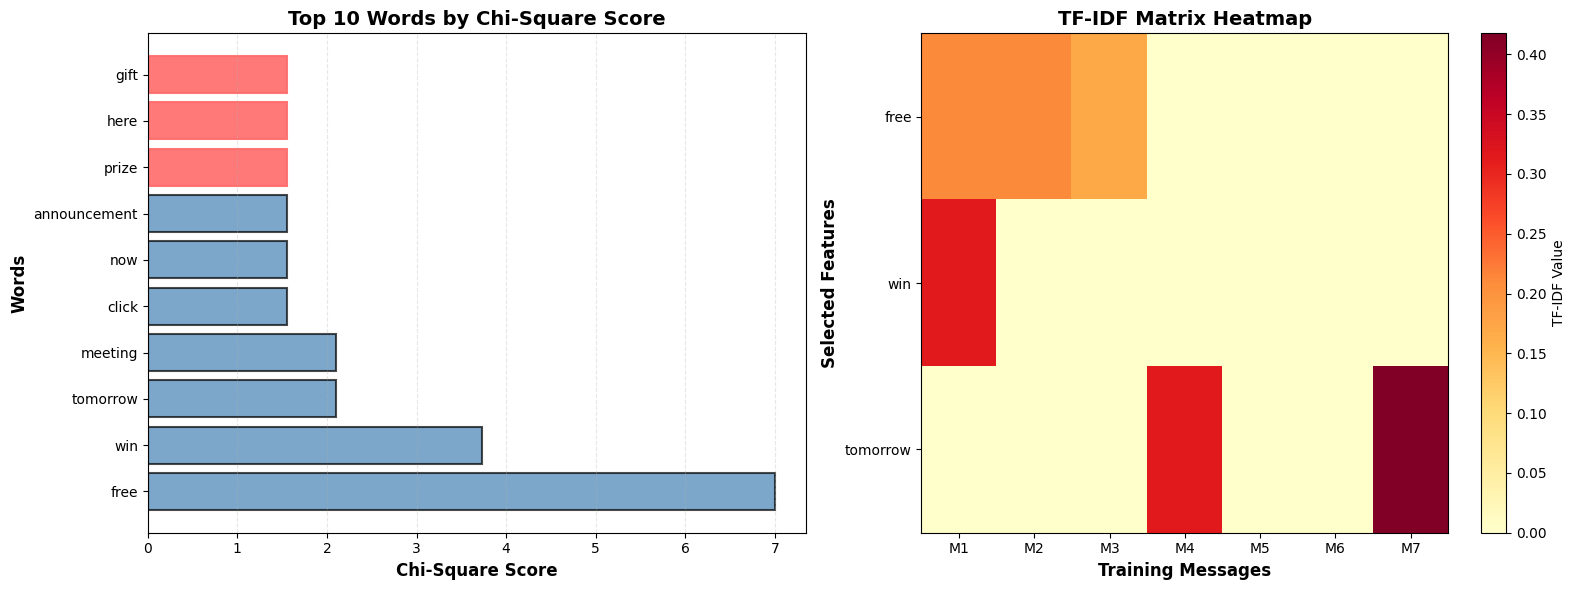

In [5]:
def euclidean_distance(vec1, vec2):
    """Calculate Euclidean distance between two vectors"""
    return sqrt(sum((a - b) ** 2 for a, b in zip(vec1, vec2)))

def cosine_distance(vec1, vec2):
    """Calculate Cosine distance between two vectors"""
    dot_product = sum(a * b for a, b in zip(vec1, vec2))
    mag1 = sqrt(sum(a ** 2 for a in vec1))
    mag2 = sqrt(sum(b ** 2 for b in vec2))
    
    if mag1 == 0 or mag2 == 0:
        return 1.0
    
    similarity = dot_product / (mag1 * mag2)
    return 1 - similarity  # Convert similarity to distance

def knn_classify(test_vector, training_vectors, labels, k=3, distance_metric='euclidean'):
    """Classify using k-nearest neighbors"""
    distances = []
    
    for i, train_vector in enumerate(training_vectors):
        if distance_metric == 'euclidean':
            dist = euclidean_distance(test_vector, train_vector)
        else:
            dist = cosine_distance(test_vector, train_vector)
        
        distances.append((dist, labels[i], i))
    
    # Sort by distance
    distances.sort(key=lambda x: x[0])
    
    # Get k nearest neighbors
    k_nearest = distances[:k]
    
    # Vote for class
    votes = Counter([label for _, label, _ in k_nearest])
    predicted_class = votes.most_common(1)[0][0]
    
    return predicted_class, k_nearest

# Classify test messages
print("="*80)
print("KNN CLASSIFICATION RESULTS (k=3)")
print("="*80)

results = []

for idx, (test_vec, test_msg) in enumerate(zip(test_tfidf_matrix, test_messages), 1):
    print(f"\n{'='*80}")
    print(f"Test Message {idx}: '{test_msg}'")
    print(f"TF-IDF Vector: {[f'{v:.4f}' for v in test_vec]}")
    
    # Euclidean distance
    print("\n--- Using Euclidean Distance ---")
    predicted, neighbors = knn_classify(test_vec, tfidf_matrix, labels, k=3, distance_metric='euclidean')
    
    print(f"3 Nearest Neighbors:")
    for dist, label, msg_idx in neighbors:
        print(f"  • [{label}] '{training_messages[msg_idx][0]}' (distance: {dist:.4f})")
    
    print(f"✓ Predicted Class (Euclidean): {predicted}")
    
    # Cosine distance
    print("\n--- Using Cosine Distance ---")
    predicted_cos, neighbors_cos = knn_classify(test_vec, tfidf_matrix, labels, k=3, distance_metric='cosine')
    
    print(f"3 Nearest Neighbors:")
    for dist, label, msg_idx in neighbors_cos:
        print(f"  • [{label}] '{training_messages[msg_idx][0]}' (distance: {dist:.4f})")
    
    print(f"✓ Predicted Class (Cosine): {predicted_cos}")
    
    results.append({
        'Test Message': test_msg,
        'Euclidean Prediction': predicted,
        'Cosine Prediction': predicted_cos
    })

print(f"\n{'='*80}")
print("CLASSIFICATION SUMMARY")
print("="*80)
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Chi-Square Scores
ax1 = axes[0]
words_sorted = [w for w, _ in sorted_features[:10]]
scores_sorted = [s for _, s in sorted_features[:10]]
bars = ax1.barh(words_sorted, scores_sorted, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Chi-Square Score', fontweight='bold', fontsize=12)
ax1.set_ylabel('Words', fontweight='bold', fontsize=12)
ax1.set_title('Top 10 Words by Chi-Square Score', fontweight='bold', fontsize=14)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Highlight top 3
for i in range(min(3, len(bars))):
    bars[-(i+1)].set_color('#FF6B6B')
    bars[-(i+1)].set_alpha(0.9)

# Plot 2: TF-IDF Heatmap
ax2 = axes[1]
tfidf_array = np.array(tfidf_matrix)
im = ax2.imshow(tfidf_array.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax2.set_xlabel('Training Messages', fontweight='bold', fontsize=12)
ax2.set_ylabel('Selected Features', fontweight='bold', fontsize=12)
ax2.set_title('TF-IDF Matrix Heatmap', fontweight='bold', fontsize=14)
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_features)
ax2.set_xticks(range(len(training_messages)))
ax2.set_xticklabels([f"M{i+1}" for i in range(len(training_messages))])

# Add colorbar
cbar = plt.colorbar(im, ax=ax2, label='TF-IDF Value')

plt.tight_layout()
plt.savefig('task2_spam_classification.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: task2_spam_classification.png")
plt.show()

## **TASK 3: TOPIC MODELING WITH BERTOPIC**

### **Step 1: Dataset Creation**

In [6]:
# Install required packages if not already installed
# !pip install bertopic scikit-learn sentence-transformers

from sklearn.datasets import fetch_20newsgroups
import pandas as pd

# Select 3 categories: sports, space, and medicine
categories = ['rec.sport.baseball', 'sci.space', 'sci.med']

print("="*60)
print("TASK 3: TOPIC MODELING WITH BERTOPIC")
print("="*60)
print(f"\nSelected Categories:")
for i, cat in enumerate(categories, 1):
    print(f"  {i}. {cat}")

# Fetch the dataset
newsgroups = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),  # Clean data
    shuffle=True,
    random_state=42
)

# Create a list of documents
docs = newsgroups.data
labels_true = newsgroups.target
label_names = newsgroups.target_names

print(f"\nDataset Statistics:")
print(f"  Total documents: {len(docs)}")
print(f"  Categories: {label_names}")
print(f"  Documents per category:")
for i, name in enumerate(label_names):
    count = sum(1 for label in labels_true if label == i)
    print(f"    - {name}: {count} documents")

# Show sample documents
print(f"\nSample Documents:")
print("-" * 60)
for i in range(3):
    print(f"\nDocument {i+1} [{label_names[labels_true[i]]}]:")
    print(f"{docs[i][:200]}...")
    print("-" * 60)

TASK 3: TOPIC MODELING WITH BERTOPIC

Selected Categories:
  1. rec.sport.baseball
  2. sci.space
  3. sci.med

Dataset Statistics:
  Total documents: 2971
  Categories: ['rec.sport.baseball', 'sci.med', 'sci.space']
  Documents per category:
    - rec.sport.baseball: 994 documents
    - sci.med: 990 documents
    - sci.space: 987 documents

Sample Documents:
------------------------------------------------------------

Document 1 [sci.med]:
I heard a great Civil War story...      A guy on the battlfield is shot
in the groin,   the bullet continues on it's path, and lodges in the
abdomen of a female spectator.    Lo and behold....

As the...
------------------------------------------------------------

Document 2 [sci.space]:
I need as much information about Cosmos 2238 and its rocket fragment (1993-
018B) as possible. Both its purpose, launch date, location, in short,
EVERYTHING! Can you help?

-Tony Ryan, "Astronomy & Sp...
------------------------------------------------------------

### **Step 2: Model Training**

In [7]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

print("Training BERTopic model in supervised mode...")
print("Using category labels to create exactly 3 topics.")

# Create a custom CountVectorizer 
vectorizer_model = CountVectorizer(
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    stop_words='english'
)

# Use a CTFIDF model with BM25 weighting to improve topic representation
ctfidf_model = ClassTfidfTransformer(bm25_weighting=True, reduce_frequent_words=True)

# Use UMAP with fewer components to preserve the 3 main clusters
umap_model = UMAP(n_components=3, n_neighbors=15, min_dist=0.0, random_state=42)

# Use HDBSCAN with larger min_cluster_size to get fewer, larger topics
# This prevents creating too many micro-topics
hdbscan_model = HDBSCAN(min_cluster_size=300, min_samples=10, 
                        metric='euclidean', prediction_data=True)

# Initialize BERTopic for supervised learning
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
)

# Fit the model in supervised mode by passing the true labels
# The large min_cluster_size should create approximately 3 main topics
topics, probabilities = topic_model.fit_transform(docs, y=labels_true)


print("\n" + "="*60)
print("MODEL TRAINING COMPLETED")
print("="*60)

# Get number of topics (excluding outliers topic -1)
num_topics = len(set(topics)) - (1 if -1 in topics else 0)
print(f"\nNumber of topics discovered: {num_topics}")

# Show topic info
topic_info = topic_model.get_topic_info()
print("\nTopic Summary:")
print("="*60)
# Displaying only the key columns for a cleaner summary
print(topic_info[["Topic", "Count", "Name"]].to_string())

2025-12-17 22:11:19,262 - BERTopic - Embedding - Transforming documents to embeddings.


Training BERTopic model in supervised mode...
Using category labels to create exactly 3 topics.


Batches:   0%|          | 0/93 [00:00<?, ?it/s]

2025-12-17 22:11:55,799 - BERTopic - Embedding - Completed ✓
2025-12-17 22:11:55,800 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-17 22:12:08,003 - BERTopic - Dimensionality - Completed ✓
2025-12-17 22:12:08,004 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-17 22:12:08,052 - BERTopic - Cluster - Completed ✓
2025-12-17 22:12:08,058 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-17 22:12:08,438 - BERTopic - Representation - Completed ✓



MODEL TRAINING COMPLETED

Number of topics discovered: 3

Topic Summary:
   Topic  Count                              Name
0      0   1060     0_patients_treatment_hiv_aids
1      1    958     1_launch_nasa_shuttle_mission
2      2    953  2_player_pitching_stats_pitchers


### **Step 3: Topic Analysis**

In [8]:
print("="*60)
print("TOPIC ANALYSIS")
print("="*60)

# Get ALL unique topic IDs (including those from actual assignments)
all_topic_ids = sorted([t for t in set(topics) if t != -1])

print(f"\nActual topics found in assignments: {all_topic_ids}")
print(f"Total unique topics: {len(all_topic_ids)}")

# Get top 5 words per topic
print("\nTop 5 Words per Topic:")
print("-" * 60)

topic_labels = {}

# Iterate through all actual topic IDs found in the data
for topic_id in all_topic_ids:
    topic_words = topic_model.get_topic(topic_id)
    if topic_words:
        words = [word for word, score in topic_words[:5]]
        print(f"\nTopic {topic_id}:")
        print(f"  Top 5 words: {', '.join(words)}")
        
        # Join all top 10 words for better matching
        all_words = ' '.join([word for word, score in topic_words[:10]]).lower()
        
        # Assign meaningful names based on top words
        if any(w in all_words for w in ['game', 'team', 'player', 'baseball', 'season', 'hit', 'league', 'runs']):
            topic_labels[topic_id] = "Sports/Baseball"
        elif any(w in all_words for w in ['space', 'nasa', 'launch', 'orbit', 'mission', 'shuttle', 'satellite', 'moon', 'mars']):
            topic_labels[topic_id] = "Space/Science"
        elif any(w in all_words for w in ['medical', 'disease', 'patients', 'health', 'doctor', 'cancer', 'medicine', 'treatment', 'hospital', 'drug', 'pain', 'vitamin']):
            topic_labels[topic_id] = "Medicine/Health"
        else:
            topic_labels[topic_id] = f"Topic_{topic_id}"
        
        print(f"  Assigned label: '{topic_labels[topic_id]}'")
        
        # Show all top words with scores
        print(f"  Detailed words (with scores):")
        for word, score in topic_words[:10]:
            print(f"    - {word}: {score:.4f}")

# Create document-topic assignment table
print("\n\nDocument-Topic Assignment Table (first 20 documents):")
print("="*80)

doc_topic_data = []
for i in range(min(20, len(docs))):
    doc_preview = docs[i][:60].replace('\n', ' ') + "..."
    true_label = label_names[labels_true[i]]
    topic_id = topics[i]
    
    if topic_id == -1:
        assigned_topic = "Outlier"
    else:
        assigned_topic = topic_labels.get(topic_id, f"Topic_{topic_id}")
    
    doc_topic_data.append({
        'Doc ID': i,
        'True Category': true_label,
        'Assigned Topic': assigned_topic,
        'Topic ID': topic_id,
        'Preview': doc_preview
    })

df_doc_topics = pd.DataFrame(doc_topic_data)
print(df_doc_topics.to_string(index=False))

# Calculate topic distribution across true categories
print("\n\nTopic Distribution Across True Categories:")
print("="*80)

distribution_data = []
for true_idx, true_name in enumerate(label_names):
    row = {'True Category': true_name}
    category_docs = [i for i, label in enumerate(labels_true) if label == true_idx]
    
    # Use all_topic_ids instead of range(num_topics)
    for topic_id in all_topic_ids:
        topic_label = topic_labels.get(topic_id, f"Topic_{topic_id}")
        count = sum(1 for i in category_docs if topics[i] == topic_id)
        percentage = (count / len(category_docs)) * 100 if category_docs else 0
        row[topic_label] = f"{count} ({percentage:.1f}%)"
    
    distribution_data.append(row)

df_distribution = pd.DataFrame(distribution_data)
print(df_distribution.to_string(index=False))

TOPIC ANALYSIS

Actual topics found in assignments: [0, 1, 2]
Total unique topics: 3

Top 5 Words per Topic:
------------------------------------------------------------

Topic 0:
  Top 5 words: patients, treatment, hiv, aids, drug
  Assigned label: 'Medicine/Health'
  Detailed words (with scores):
    - patients: 0.4762
    - treatment: 0.4281
    - hiv: 0.3988
    - aids: 0.3980
    - drug: 0.3921
    - diet: 0.3914
    - clinical: 0.3906
    - doctors: 0.3668
    - symptoms: 0.3579
    - volume number: 0.3565

Topic 1:
  Top 5 words: launch, nasa, shuttle, mission, satellite
  Assigned label: 'Space/Science'
  Detailed words (with scores):
    - launch: 0.4922
    - nasa: 0.4786
    - shuttle: 0.4568
    - mission: 0.4446
    - satellite: 0.4384
    - mars: 0.3993
    - technology: 0.3623
    - degrees: 0.3449
    - images: 0.3437
    - systems: 0.3375

Topic 2:
  Top 5 words: player, pitching, stats, pitchers, fans
  Assigned label: 'Sports/Baseball'
  Detailed words (with scores):

### **Step 4: Visualization**

Creating visualizations...
✓ Saved: task3_topic_words.html


✓ Saved: task3_topic_distance.html


✓ Saved: task3_topic_words_bar.png


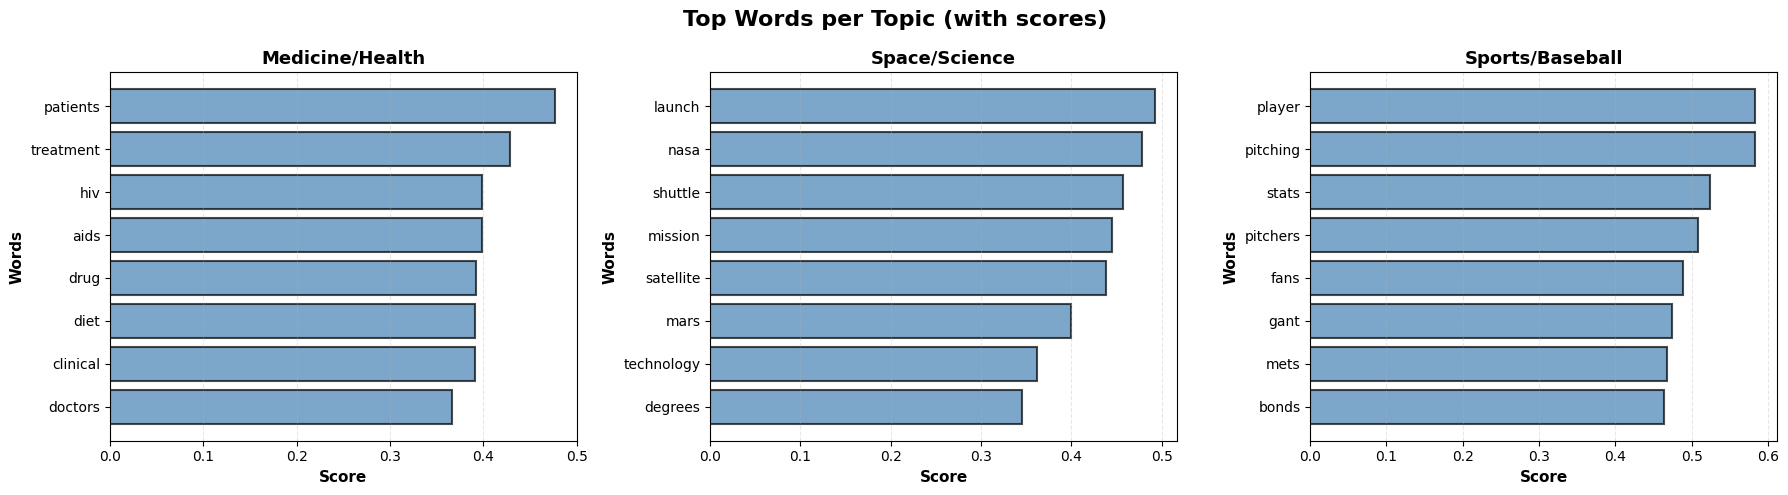

✓ Saved: task3_document_distribution.png


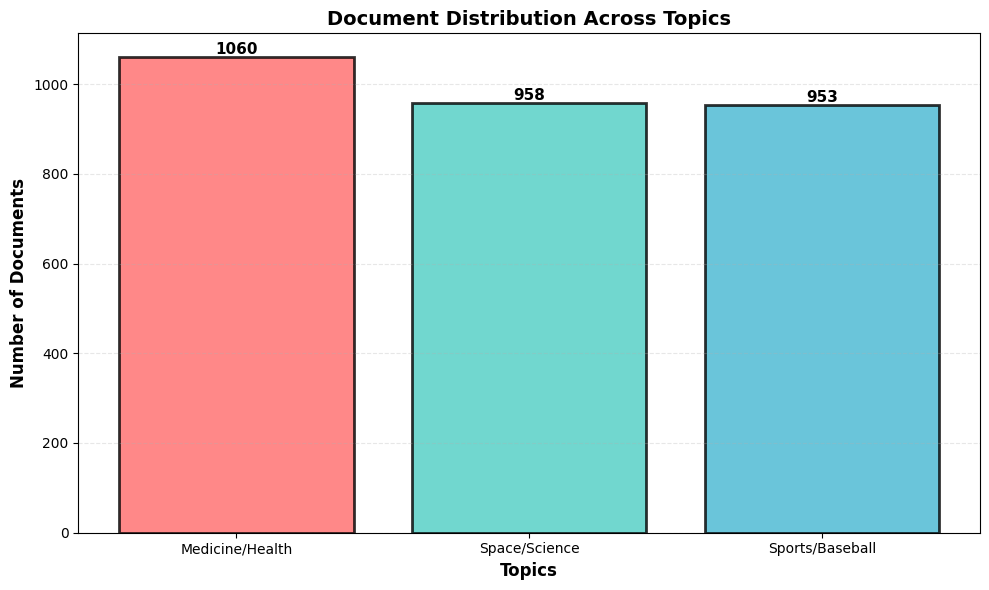

In [9]:
import matplotlib.pyplot as plt

print("Creating visualizations...")

# Visualization 1: Bar chart of top words per topic
fig = topic_model.visualize_barchart(top_n_topics=num_topics, n_words=8, height=400)
fig.write_html('task3_topic_words.html')
print("✓ Saved: task3_topic_words.html")
fig.show()

# Visualization 2: Topic distance map (intertopic distance)
try:
    fig2 = topic_model.visualize_topics()
    fig2.write_html('task3_topic_distance.html')
    print("✓ Saved: task3_topic_distance.html")
    fig2.show()
except Exception as e:
    print(f"Note: Could not create topic distance map. This requires more topics or different parameters.")
    print(f"Error: {e}")

# Additional visualization: Topic word scores
fig, axes = plt.subplots(1, min(3, num_topics), figsize=(18, 5))
if num_topics == 1:
    axes = [axes]

fig.suptitle('Top Words per Topic (with scores)', fontsize=16, fontweight='bold')

for idx, topic_id in enumerate(range(min(3, num_topics))):
    ax = axes[idx] if num_topics > 1 else axes[0]
    
    topic_words = topic_model.get_topic(topic_id)
    if topic_words:
        words = [word for word, score in topic_words[:8]]
        scores = [score for word, score in topic_words[:8]]
        
        bars = ax.barh(words, scores, color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)
        ax.set_xlabel('Score', fontweight='bold', fontsize=11)
        ax.set_ylabel('Words', fontweight='bold', fontsize=11)
        
        topic_label = topic_labels.get(topic_id, f"Topic {topic_id}")
        ax.set_title(f'{topic_label}', fontweight='bold', fontsize=13)
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        ax.invert_yaxis()

plt.tight_layout()
plt.savefig('task3_topic_words_bar.png', dpi=300, bbox_inches='tight')
print("✓ Saved: task3_topic_words_bar.png")
plt.show()

# Visualization 3: Document distribution across topics
topic_counts = {}
for topic_id in topics:
    if topic_id != -1:
        topic_label = topic_labels.get(topic_id, f"Topic_{topic_id}")
        topic_counts[topic_label] = topic_counts.get(topic_label, 0) + 1

fig, ax = plt.subplots(figsize=(10, 6))
labels = list(topic_counts.keys())
counts = list(topic_counts.values())

bars = ax.bar(labels, counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1'][:len(labels)], 
              alpha=0.8, edgecolor='black', linewidth=2)

ax.set_xlabel('Topics', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Documents', fontweight='bold', fontsize=12)
ax.set_title('Document Distribution Across Topics', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(height)}',
           ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('task3_document_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: task3_document_distribution.png")
plt.show()

### **Step 5: New Document Test**

In [10]:
# Write 3 new articles (one per category)
new_articles = [
    # Sports/Baseball article
    """
    The baseball team had an incredible victory last night at the stadium.
    The pitcher threw an amazing game with 12 strikeouts and the team scored
    7 runs in the final innings. The player of the match hit two home runs
    and helped secure the championship win for the season.
    """,
    
    # Space/Science article  
    """
    NASA announced a new space mission to explore Mars next year. The space
    shuttle will launch from Kennedy Space Center carrying scientific equipment
    to study the Martian atmosphere. The mission will orbit the planet for
    six months collecting data about potential water sources and geological features.
    """,
    
    # Medicine article
    """
    A new study on disease prevention was published by leading doctors. The
    research shows that regular exercise and a balanced diet can significantly
    reduce the risk of heart conditions. The findings suggest that patients
    should focus on lifestyle changes to improve their overall health.
    """
]

article_labels = ['Sports/Baseball', 'Space/Science', 'Medicine']

print("="*60)
print("NEW DOCUMENT PREDICTION")
print("="*60)

predictions_data = []

for i, (article, expected_label) in enumerate(zip(new_articles, article_labels), 1):
    print(f"\n{'='*80}")
    print(f"New Article {i}: {expected_label}")
    print("-" * 80)
    print(article.strip())
    print("-" * 80)
    
    # Predict topic for the new article
    predicted_topic, predicted_prob = topic_model.transform([article])
    topic_id = predicted_topic[0]
    
    if topic_id == -1:
        predicted_label = "Outlier (no clear topic)"
    else:
        predicted_label = topic_labels.get(topic_id, f"Topic_{topic_id}")
    
    print(f"\n✓ Predicted Topic: {predicted_label} (Topic ID: {topic_id})")
    print(f"✓ Expected Category: {expected_label}")
    print(f"✓ Confidence: {predicted_prob[0]:.4f}")
    
    # Show the words in the predicted topic
    if topic_id != -1:
        topic_words = topic_model.get_topic(topic_id)
        if topic_words:
            words = [word for word, score in topic_words[:5]]
            print(f"✓ Top words in predicted topic: {', '.join(words)}")
    
    match = "✓ Correct" if predicted_label.split('/')[0].lower() in expected_label.lower() else "✗ Incorrect"
    print(f"\nPrediction accuracy: {match}")
    
    predictions_data.append({
        'Article': f"Article {i}",
        'Expected': expected_label,
        'Predicted': predicted_label,
        'Topic ID': topic_id,
        'Match': match
    })

print("\n" + "="*80)
print("PREDICTION SUMMARY")
print("="*80)
df_predictions = pd.DataFrame(predictions_data)
print(df_predictions.to_string(index=False))

# Calculate accuracy
correct = sum(1 for p in predictions_data if "Correct" in p['Match'])
accuracy = (correct / len(predictions_data)) * 100
print(f"\nPrediction Accuracy: {correct}/{len(predictions_data)} = {accuracy:.1f}%")

NEW DOCUMENT PREDICTION

New Article 1: Sports/Baseball
--------------------------------------------------------------------------------
The baseball team had an incredible victory last night at the stadium.
    The pitcher threw an amazing game with 12 strikeouts and the team scored
    7 runs in the final innings. The player of the match hit two home runs
    and helped secure the championship win for the season.
--------------------------------------------------------------------------------


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-12-17 22:12:12,244 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-12-17 22:12:13,821 - BERTopic - Dimensionality - Completed ✓
2025-12-17 22:12:13,822 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-12-17 22:12:13,823 - BERTopic - Cluster - Completed ✓



✓ Predicted Topic: Sports/Baseball (Topic ID: 2)
✓ Expected Category: Sports/Baseball
✓ Confidence: 0.7217
✓ Top words in predicted topic: player, pitching, stats, pitchers, fans

Prediction accuracy: ✓ Correct

New Article 2: Space/Science
--------------------------------------------------------------------------------
NASA announced a new space mission to explore Mars next year. The space
    shuttle will launch from Kennedy Space Center carrying scientific equipment
    to study the Martian atmosphere. The mission will orbit the planet for
    six months collecting data about potential water sources and geological features.
--------------------------------------------------------------------------------


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-12-17 22:12:14,012 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-12-17 22:12:14,019 - BERTopic - Dimensionality - Completed ✓
2025-12-17 22:12:14,020 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-12-17 22:12:14,020 - BERTopic - Cluster - Completed ✓



✓ Predicted Topic: Space/Science (Topic ID: 1)
✓ Expected Category: Space/Science
✓ Confidence: 1.0000
✓ Top words in predicted topic: launch, nasa, shuttle, mission, satellite

Prediction accuracy: ✓ Correct

New Article 3: Medicine
--------------------------------------------------------------------------------
A new study on disease prevention was published by leading doctors. The
    research shows that regular exercise and a balanced diet can significantly
    reduce the risk of heart conditions. The findings suggest that patients
    should focus on lifestyle changes to improve their overall health.
--------------------------------------------------------------------------------


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2025-12-17 22:12:14,120 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-12-17 22:12:14,127 - BERTopic - Dimensionality - Completed ✓
2025-12-17 22:12:14,127 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-12-17 22:12:14,128 - BERTopic - Cluster - Completed ✓



✓ Predicted Topic: Medicine/Health (Topic ID: 0)
✓ Expected Category: Medicine
✓ Confidence: 0.7200
✓ Top words in predicted topic: patients, treatment, hiv, aids, drug

Prediction accuracy: ✓ Correct

PREDICTION SUMMARY
  Article        Expected       Predicted  Topic ID     Match
Article 1 Sports/Baseball Sports/Baseball         2 ✓ Correct
Article 2   Space/Science   Space/Science         1 ✓ Correct
Article 3        Medicine Medicine/Health         0 ✓ Correct

Prediction Accuracy: 3/3 = 100.0%
